1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

2. Load Data

In [2]:
ledger = pd.read_csv("ledger.csv")
gateway = pd.read_csv("gateway_export.csv")
merchants = pd.read_csv("merchants.csv")

ledger["transaction_time"] = pd.to_datetime(ledger["transaction_time"])

3. Headline Layer (Scorecards)

In [9]:
# Total GMV
total_gmv = ledger["amount_inr"].sum()

# Success Rate
success_rate = (
    (ledger["status"] == "success").sum()
    / len(ledger)
) * 100

# Reconciliation Match Rate
merged = pd.merge(
    ledger,
    gateway,
    on="transaction_id",
    suffixes=("_ledger", "_gateway")
)

matched = merged[
    (merged["amount_inr_ledger"] == merged["amount_inr_gateway"]) &
    (merged["status_ledger"] == merged["status_gateway"])
]

match_rate = (len(matched) / len(ledger)) * 100

# Chargeback Ratio
chargeback_ratio = (
    (ledger["status"] == "chargeback").sum()
    / len(ledger)
) * 100

Display Scorecards

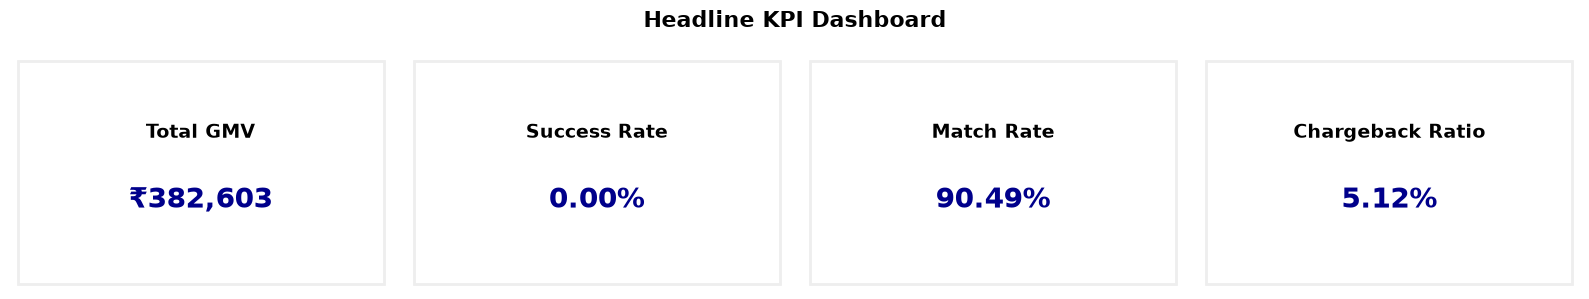

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

scorecards = [
    ("Total GMV", f"₹{total_gmv:,.0f}"),
    ("Success Rate", f"{success_rate:.2f}%"),
    ("Match Rate", f"{match_rate:.2f}%"),
    ("Chargeback Ratio", f"{chargeback_ratio:.2f}%")
]

for ax, (title, value) in zip(axes, scorecards):
    ax.axis("off")

    ax.text(
        0.5,
        0.65,
        title,
        fontsize=14,
        fontweight="bold",
        ha="center"
    )

    ax.text(
        0.5,
        0.35,
        value,
        fontsize=20,
        color="darkblue",
        fontweight="bold",
        ha="center"
    )

    # Draw border box
    ax.add_patch(
        plt.Rectangle(
            (0.02, 0.02),
            0.96,
            0.96,
            fill=False,
            lw=2,
            transform=ax.transAxes
        )
    )

plt.suptitle(
    "Headline KPI Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "headline_scorecards.png",
    bbox_inches="tight"
)

plt.show()

4. Trends Layer

In [11]:
# Daily GMV
daily_gmv = (
    ledger.groupby(
        ledger["transaction_time"].dt.date
    )["amount_inr"]
    .sum()
    .reset_index()
)

# Daily Chargebacks
daily_chargebacks = (
    ledger[
        ledger["status"] == "chargeback"
    ]
    .groupby(
        ledger["transaction_time"].dt.date
    )
    .size()
    .reset_index(name="chargebacks")
)

Plot

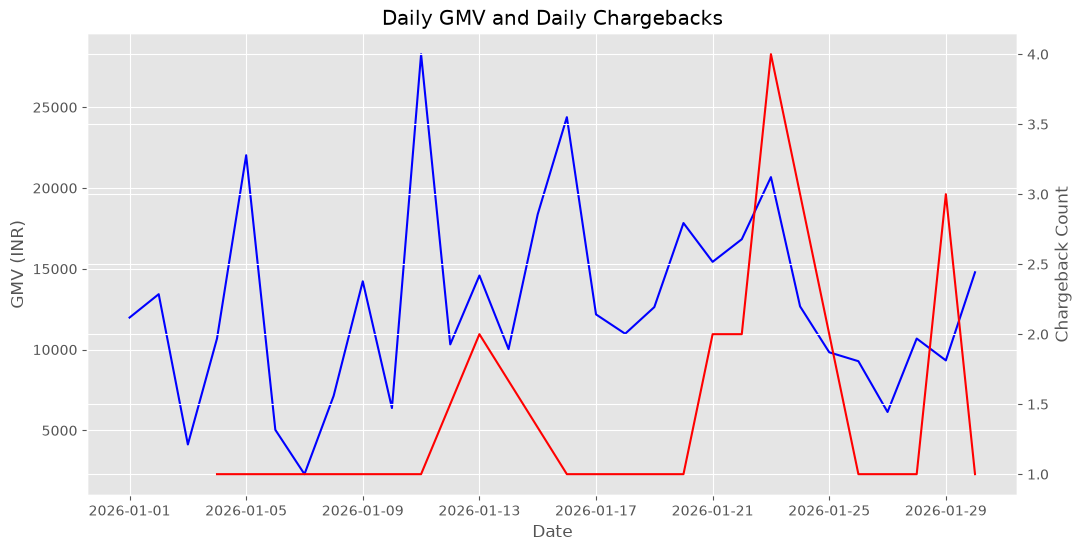

In [12]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    daily_gmv["transaction_time"],
    daily_gmv["amount_inr"],
    color="blue",
    label="Daily GMV"
)

ax1.set_ylabel("GMV (INR)")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    daily_chargebacks["transaction_time"],
    daily_chargebacks["chargebacks"],
    color="red",
    label="Chargebacks"
)

ax2.set_ylabel("Chargeback Count")

plt.title(
    "Daily GMV and Daily Chargebacks"
)

plt.savefig(
    "trend_layer.png",
    bbox_inches="tight"
)

plt.show()

5. Breakdown Layer

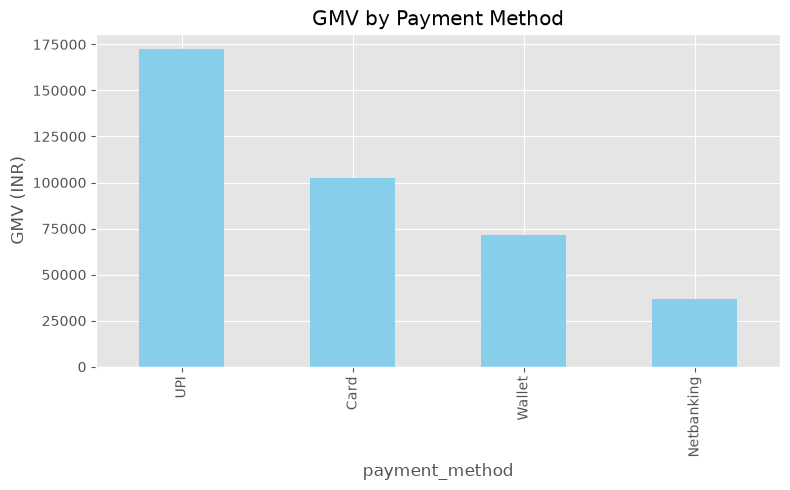

In [13]:
ledger_merchant = pd.merge(
    ledger,
    merchants,
    on="merchant_id",
    how="left"
)

# GMV by Payment Method
payment_gmv = (
    ledger.groupby("payment_method")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)


# Display
plt.figure(figsize=(8,5))

payment_gmv.plot(
    kind="bar",
    color="skyblue"
)

plt.title("GMV by Payment Method")
plt.ylabel("GMV (INR)")

plt.tight_layout()

plt.savefig(
    "gmv_payment_method.png"
)

plt.show()

GMV by Merchant Category

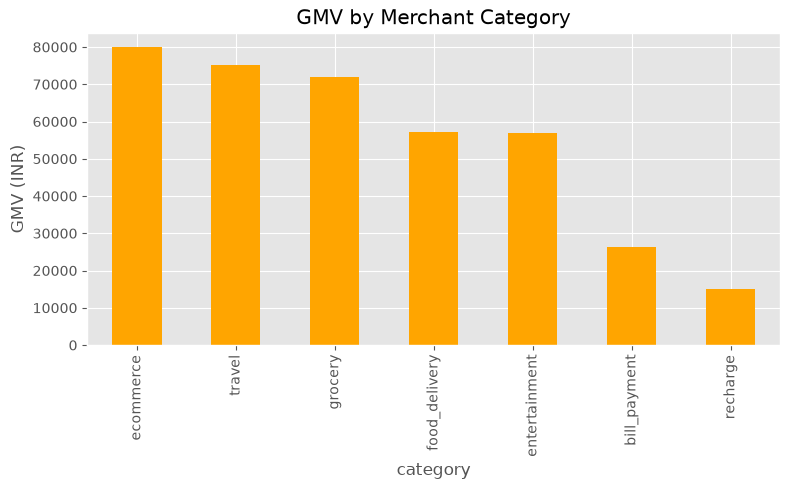

In [14]:
category_gmv = (
    ledger_merchant.groupby("category")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_gmv.plot(
    kind="bar",
    color="orange"
)

plt.title("GMV by Merchant Category")
plt.ylabel("GMV (INR)")

plt.tight_layout()

plt.savefig(
    "gmv_category.png"
)

plt.show()

6. Details Layer

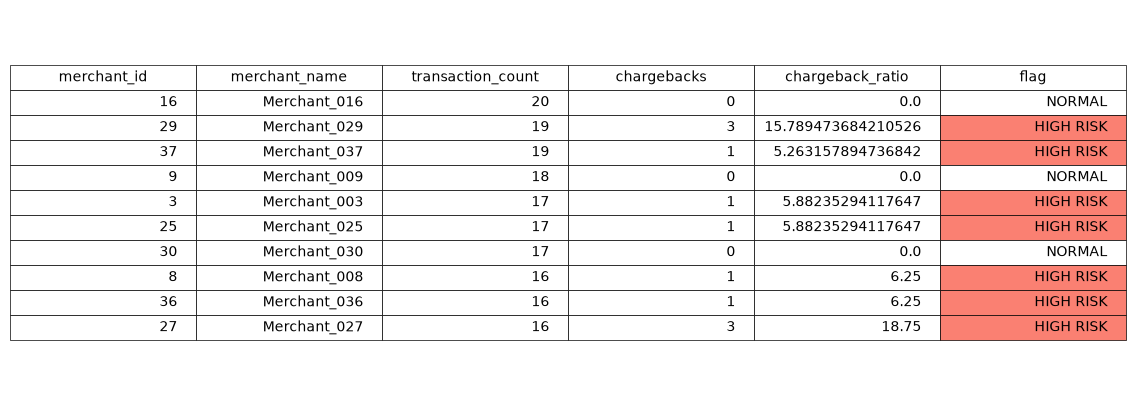

In [15]:
# Top 10 Merchants by Transaction Count
merchant_stats = (
    ledger_merchant
    .groupby(
        ["merchant_id",
         "merchant_name"]
    )
    .agg(
        transaction_count=(
            "transaction_id",
            "count"
        ),
        chargebacks=(
            "status",
            lambda x:
            (x=="chargeback").sum()
        )
    )
    .reset_index()
)

# Chargeback Ratio
merchant_stats["chargeback_ratio"] = (
    merchant_stats["chargebacks"]
    / merchant_stats["transaction_count"]
) * 100

# Flag >1%
merchant_stats["flag"] = merchant_stats[
    "chargeback_ratio"
].apply(
    lambda x:
    "HIGH RISK"
    if x > 1
    else "NORMAL"
)

# Top 10
top10 = (
    merchant_stats
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .head(10)
)

# Display
fig, ax = plt.subplots(
    figsize=(12,5)
)

ax.axis("off")

table = ax.table(
    cellText=top10.values,
    colLabels=top10.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

flag_col = top10.columns.get_loc("flag")

for i, row in enumerate(
    top10.itertuples(),
    start=1
):
    if row.flag == "HIGH RISK":
        table[(i, flag_col)].set_facecolor(
            "salmon"
        )

plt.savefig(
    "merchant_detail_table.png",
    bbox_inches="tight"
)

plt.show()